In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries imported")


Libraries imported


In [2]:
n = 2000

crop_types = np.random.choice(['Wheat','Rice','Cotton','Sugarcane','Maize'], n,
                               p=[0.30,0.25,0.20,0.15,0.10])
soil_quality = np.random.choice(['Poor','Medium','Good'], n, p=[0.25,0.50,0.25])
rainfall_mm  = np.random.normal(850, 200, n).clip(200, 1800)
temperature_c = np.random.normal(27, 4, n).clip(18, 40)
farm_size    = np.random.exponential(3.5, n).clip(0.5, 30)
irrigation   = np.random.binomial(1, 0.45, n)
fertilizer   = np.random.choice(['Low','Medium','High'], n, p=[0.30,0.45,0.25])
prev_claims  = np.random.choice([0,1,2,3], n, p=[0.55,0.25,0.15,0.05])
disaster_yr  = np.random.binomial(1, 0.18, n)

soil_map  = {'Poor': 0, 'Medium': 1, 'Good': 2}
fert_map  = {'Low': 0, 'Medium': 1, 'High': 2}
crop_yield_base = {'Wheat':18,'Rice':22,'Cotton':12,'Sugarcane':300,'Maize':20}

hist_yield = np.array([
    crop_yield_base[c] * (1 + soil_map[s]*0.15) * (1 + irrigation[i]*0.2)
    * (1 + fert_map[f]*0.1) * np.random.normal(1, 0.12)
    for i,(c,s,f) in enumerate(zip(crop_types, soil_quality, fertilizer))
])

claim_prob = (
    0.08
    + disaster_yr        * 0.35
    + (prev_claims > 0)  * 0.20
    + (soil_quality == 'Poor').astype(int) * 0.10
    + (rainfall_mm < 600).astype(int) * 0.12
    + (irrigation == 0)  * 0.06
    + (temperature_c > 34).astype(int) * 0.05
    + np.random.normal(0, 0.05, n)
).clip(0, 1)

claim_filed = (np.random.uniform(0,1,n) < claim_prob).astype(int)

df = pd.DataFrame({
    'crop_type':           crop_types,
    'soil_quality':        soil_quality,
    'rainfall_mm':         rainfall_mm.round(1),
    'temperature_c':       temperature_c.round(1),
    'farm_size_acres':     farm_size.round(2),
    'historical_yield_q':  hist_yield.round(1),
    'prev_claims':         prev_claims,
    'irrigation':          irrigation,
    'fertilizer_usage':    fertilizer,
    'disaster_year':       disaster_yr,
    'claim_filed':         claim_filed,
})

print("Dataset shape:", df.shape)
print(f"\nClaim rate: {df['claim_filed'].mean()*100:.1f}%")
print(df['claim_filed'].value_counts().rename({1:'Claim Filed', 0:'No Claim'}))
df.head(10)


Dataset shape: (2000, 11)

Claim rate: 30.6%
claim_filed
No Claim       1389
Claim Filed     611
Name: count, dtype: int64


,crop_type,soil_quality,rainfall_mm,temperature_c,farm_size_acres,historical_yield_q,prev_claims,irrigation,fertilizer_usage,disaster_year,claim_filed
0,Rice,Medium,1115.7,26.3,1.40,31.1,0,1,Low,0,0
1,Maize,Poor,912.6,22.5,0.52,21.6,0,0,Low,0,0
2,Cotton,Good,728.7,28.1,1.78,22.2,2,1,Medium,0,0
3,Cotton,Poor,941.2,18.7,13.68,18.9,0,1,High,0,0
4,Wheat,Medium,758.2,26.6,0.90,21.8,1,0,Medium,0,0
5,Wheat,Good,711.1,27.1,3.32,29.1,0,1,Medium,1,0
6,Wheat,Medium,619.1,30.2,1.99,20.1,0,1,Low,0,0
7,Sugarcane,Good,499.6,30.9,0.50,547.1,1,1,Medium,0,1
8,Cotton,Poor,772.0,25.0,2.34,13.6,0,0,Low,1,0
9,Cotton,Medium,881.6,26.4,4.24,16.5,0,0,Low,0,0


In [3]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print()
print("Data types:")
print(df.dtypes)


Missing values: 0
Duplicate rows: 0

Data types:
crop_type              object
soil_quality           object
rainfall_mm           float64
temperature_c         float64
farm_size_acres       float64
historical_yield_q    float64
prev_claims             int64
irrigation              int32
fertilizer_usage       object
disaster_year           int32
claim_filed             int64
dtype: object


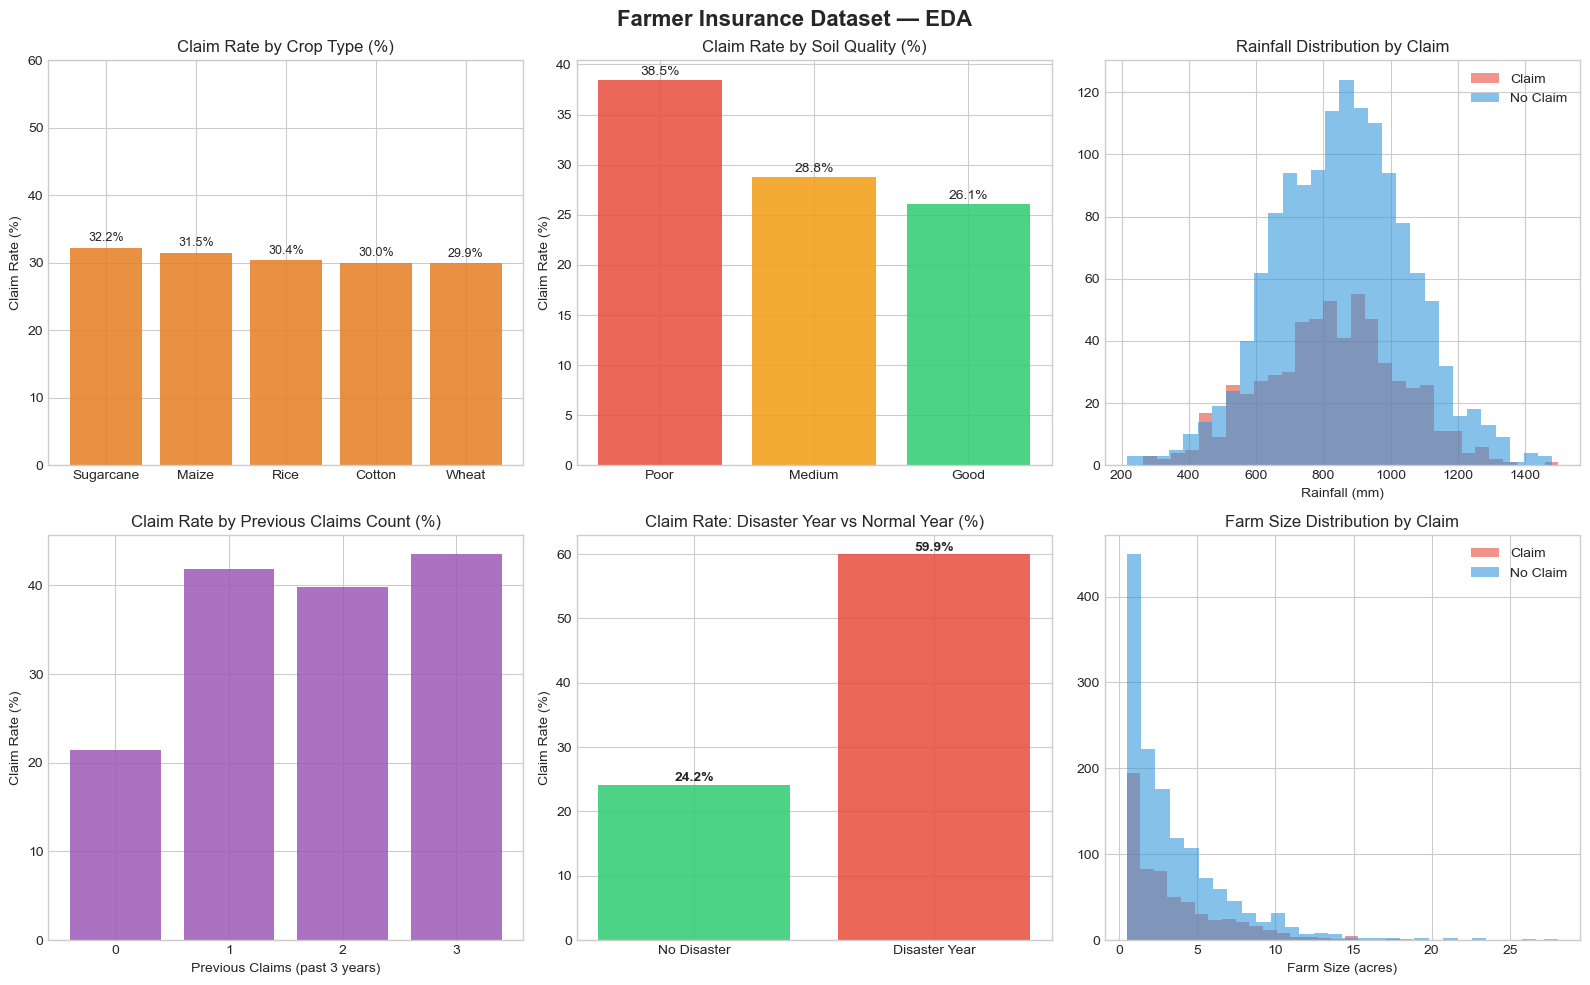

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Farmer Insurance Dataset — EDA', fontsize=16, fontweight='bold')

crop_claim = df.groupby('crop_type')['claim_filed'].mean().sort_values(ascending=False)
axes[0,0].bar(crop_claim.index, crop_claim.values*100, color='#e67e22', alpha=0.85)
axes[0,0].set_title('Claim Rate by Crop Type (%)')
axes[0,0].set_ylabel('Claim Rate (%)')
axes[0,0].set_ylim(0, 60)
for i, v in enumerate(crop_claim.values):
    axes[0,0].text(i, v*100+1, f'{v*100:.1f}%', ha='center', fontsize=9)

soil_claim = df.groupby('soil_quality')['claim_filed'].mean()
soil_order = ['Poor','Medium','Good']
axes[0,1].bar(soil_order, [soil_claim[s]*100 for s in soil_order],
               color=['#e74c3c','#f39c12','#2ecc71'], alpha=0.85)
axes[0,1].set_title('Claim Rate by Soil Quality (%)')
axes[0,1].set_ylabel('Claim Rate (%)')
for i, s in enumerate(soil_order):
    axes[0,1].text(i, soil_claim[s]*100+0.5, f'{soil_claim[s]*100:.1f}%', ha='center')

for label, color, name in [(1,'#e74c3c','Claim'), (0,'#3498db','No Claim')]:
    axes[0,2].hist(df[df['claim_filed']==label]['rainfall_mm'],
                   bins=30, alpha=0.6, label=name, color=color)
axes[0,2].set_title('Rainfall Distribution by Claim')
axes[0,2].set_xlabel('Rainfall (mm)')
axes[0,2].legend()

prev_claim_rate = df.groupby('prev_claims')['claim_filed'].mean()*100
axes[1,0].bar(prev_claim_rate.index.astype(str), prev_claim_rate.values,
               color='#9b59b6', alpha=0.85)
axes[1,0].set_title('Claim Rate by Previous Claims Count (%)')
axes[1,0].set_xlabel('Previous Claims (past 3 years)')
axes[1,0].set_ylabel('Claim Rate (%)')

disaster_rate = df.groupby('disaster_year')['claim_filed'].mean()*100
axes[1,1].bar(['No Disaster','Disaster Year'], disaster_rate.values,
               color=['#2ecc71','#e74c3c'], alpha=0.85)
axes[1,1].set_title('Claim Rate: Disaster Year vs Normal Year (%)')
axes[1,1].set_ylabel('Claim Rate (%)')
for i, v in enumerate(disaster_rate.values):
    axes[1,1].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

for label, color, name in [(1,'#e74c3c','Claim'), (0,'#3498db','No Claim')]:
    axes[1,2].hist(df[df['claim_filed']==label]['farm_size_acres'],
                   bins=30, alpha=0.6, label=name, color=color)
axes[1,2].set_title('Farm Size Distribution by Claim')
axes[1,2].set_xlabel('Farm Size (acres)')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('farmer_eda.png', dpi=120, bbox_inches='tight')
plt.show()


In [5]:
df_model = df.copy()

le_crop = LabelEncoder()
le_soil = LabelEncoder()
le_fert = LabelEncoder()

df_model['crop_type']       = le_crop.fit_transform(df_model['crop_type'])
df_model['soil_quality']    = le_soil.fit_transform(df_model['soil_quality'])
df_model['fertilizer_usage']= le_fert.fit_transform(df_model['fertilizer_usage'])

print("Categorical features encoded")
print(f"crop_type     -> {dict(zip(le_crop.classes_, le_crop.transform(le_crop.classes_)))}")
print(f"soil_quality  -> {dict(zip(le_soil.classes_, le_soil.transform(le_soil.classes_)))}")
print(f"fertilizer    -> {dict(zip(le_fert.classes_, le_fert.transform(le_fert.classes_)))}")


Categorical features encoded
crop_type     -> {'Cotton': np.int64(0), 'Maize': np.int64(1), 'Rice': np.int64(2), 'Sugarcane': np.int64(3), 'Wheat': np.int64(4)}
soil_quality  -> {'Good': np.int64(0), 'Medium': np.int64(1), 'Poor': np.int64(2)}
fertilizer    -> {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [6]:
df_model['rainfall_deficit']    = (df_model['rainfall_mm'] < 600).astype(int)
df_model['high_temp_stress']    = (df_model['temperature_c'] > 34).astype(int)
df_model['yield_per_acre']      = df_model['historical_yield_q'] / (df_model['farm_size_acres'] + 0.1)
df_model['risk_score_raw']      = (
    df_model['disaster_year'] * 3 +
    df_model['prev_claims'] * 2 +
    df_model['rainfall_deficit'] * 2 +
    (1 - df_model['irrigation']) +
    df_model['high_temp_stress']
)
df_model['unprotected_large_farm'] = (
    (df_model['farm_size_acres'] > 5) & (df_model['irrigation'] == 0)
).astype(int)

new_feats = ['rainfall_deficit','high_temp_stress','yield_per_acre',
             'risk_score_raw','unprotected_large_farm']
print("Feature correlations with claim_filed:")
for f in new_feats:
    r = df_model[f].corr(df_model['claim_filed'])
    print(f"  {f:28s}: {r:.3f}")


Feature correlations with claim_filed:
  rainfall_deficit            : 0.097
  high_temp_stress            : -0.016
  yield_per_acre              : 0.019
  risk_score_raw              : 0.346
  unprotected_large_farm      : 0.068


In [7]:
X = df_model.drop(columns=['claim_filed'])
y = df_model['claim_filed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")
print(f"Features:         {X_train.shape[1]}")
print(f"\nClaim rate in test: {y_test.mean()*100:.1f}%")


Training samples: 1600
Test samples:     400
Features:         15

Claim rate in test: 30.5%


In [8]:
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000), True),
    'Random Forest':       (RandomForestClassifier(n_estimators=200, random_state=42), False),
    'Gradient Boosting':   (GradientBoostingClassifier(n_estimators=200,
                                                        learning_rate=0.05,
                                                        max_depth=4, random_state=42), False),
}

results = {}
for name, (model, use_scale) in models.items():
    Xtr = X_train_sc if use_scale else X_train.values
    Xte = X_test_sc  if use_scale else X_test.values

    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    proba = model.predict_proba(Xte)[:,1]

    results[name] = {
        'accuracy':  accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds),
        'recall':    recall_score(y_test, preds),
        'f1':        f1_score(y_test, preds),
        'roc_auc':   roc_auc_score(y_test, proba),
        'proba': proba, 'preds': preds, 'model': model, 'use_scale': use_scale
    }
    r = results[name]
    print(f"{name:22s} | Acc: {r['accuracy']:.4f} | "
          f"Recall: {r['recall']:.4f} | F1: {r['f1']:.4f} | AUC: {r['roc_auc']:.4f}")


Logistic Regression    | Acc: 0.7250 | Recall: 0.3934 | F1: 0.4660 | AUC: 0.7569
Random Forest          | Acc: 0.7225 | Recall: 0.4098 | F1: 0.4739 | AUC: 0.7125
Gradient Boosting      | Acc: 0.7400 | Recall: 0.4344 | F1: 0.5048 | AUC: 0.7305


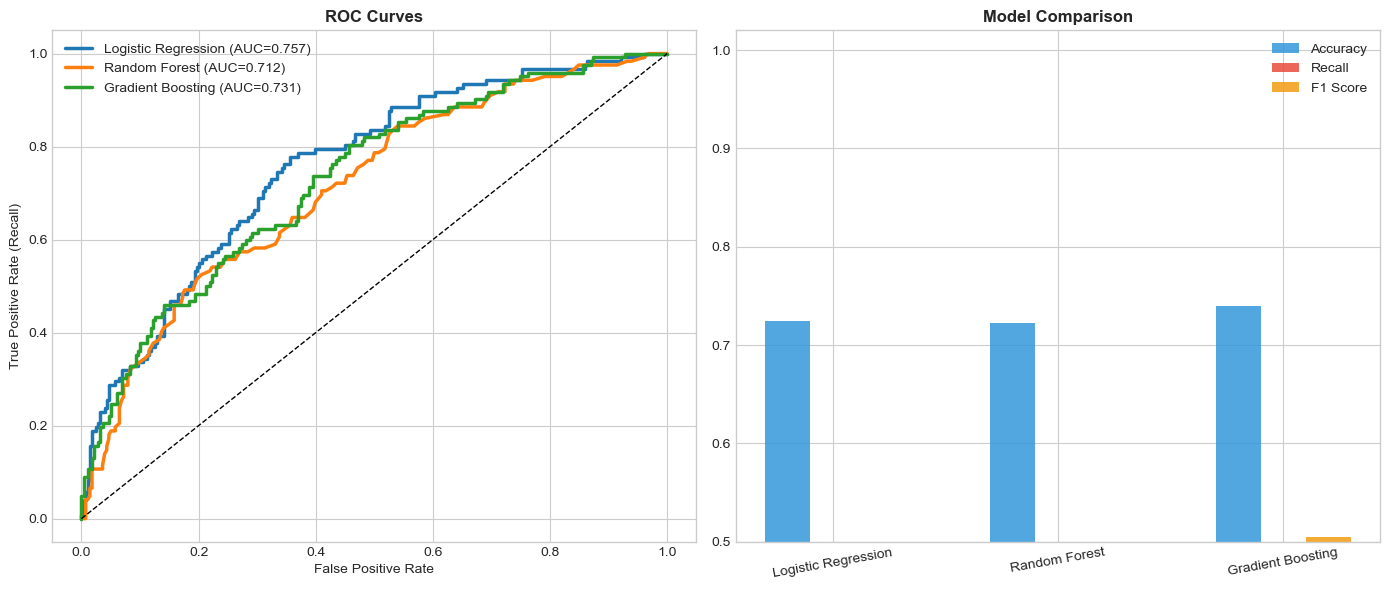


Best Model: Logistic Regression
AUC:      0.7569
Recall:   0.3934
F1:       0.4660


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    axes[0].plot(fpr, tpr, lw=2.5, label=f"{name} (AUC={res['roc_auc']:.3f})")
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_title('ROC Curves', fontsize=12, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].legend()
names = list(results.keys())
x = np.arange(len(names))
w = 0.2
axes[1].bar(x-w,   [results[n]['accuracy'] for n in names], w, label='Accuracy',  color='#3498db', alpha=0.85)
axes[1].bar(x,     [results[n]['recall']   for n in names], w, label='Recall',    color='#e74c3c', alpha=0.85)
axes[1].bar(x+w,   [results[n]['f1']       for n in names], w, label='F1 Score',  color='#f39c12', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=10)
axes[1].set_ylim(0.5, 1.02)
axes[1].set_title('Model Comparison', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('farmer_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

best_name = max(results, key=lambda k: results[k]['roc_auc'])
print(f"\nBest Model: {best_name}")
print(f"AUC:      {results[best_name]['roc_auc']:.4f}")
print(f"Recall:   {results[best_name]['recall']:.4f}")
print(f"F1:       {results[best_name]['f1']:.4f}")


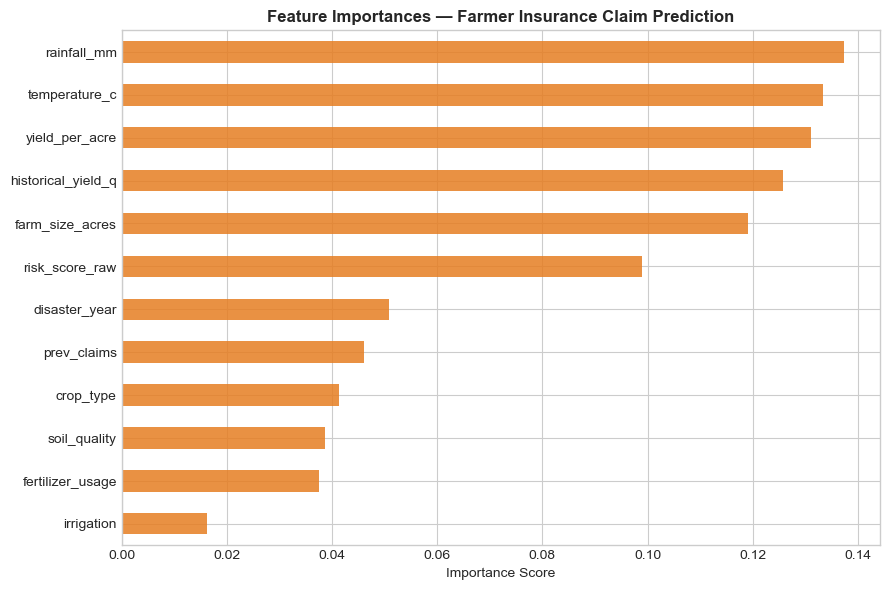

Top 5 most important features:
  irrigation                    : 0.0163
  fertilizer_usage              : 0.0375
  soil_quality                  : 0.0387
  crop_type                     : 0.0414
  prev_claims                   : 0.0461


In [10]:
rf = results['Random Forest']['model']
importances = pd.Series(rf.feature_importances_, index=X.columns)
top12 = importances.nlargest(12)

fig, ax = plt.subplots(figsize=(9, 6))
top12.sort_values().plot(kind='barh', ax=ax, color='#e67e22', alpha=0.85)
ax.set_title('Feature Importances — Farmer Insurance Claim Prediction',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('farmer_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("Top 5 most important features:")
for feat, imp in top12.tail(5)[::-1].items():
    print(f"  {feat:30s}: {imp:.4f}")


In [11]:
best_model = results[best_name]['model']
Xte = X_test_sc if results[best_name]['use_scale'] else X_test.values
claim_proba = best_model.predict_proba(Xte)[:,1]

def risk_tier(p):
    if p < 0.20:   return 'Low'
    elif p < 0.45: return 'Medium'
    elif p < 0.70: return 'High'
    else:          return 'Very High'

risk_df = X_test.copy()
risk_df['actual_claim']    = y_test.values
risk_df['claim_probability'] = claim_proba.round(3)
risk_df['risk_tier']       = [risk_tier(p) for p in claim_proba]

print("Risk Tier Distribution:")
print(risk_df['risk_tier'].value_counts())
print()
print("Actual claim rate by risk tier:")
print(risk_df.groupby('risk_tier')['actual_claim'].mean().round(3)
      .rename("Actual Claim Rate"))

risk_df[['claim_probability','risk_tier','actual_claim']].head(10)


Risk Tier Distribution:
risk_tier
Medium       173
Low          122
High          83
Very High     22
Name: count, dtype: int64

Actual claim rate by risk tier:
risk_tier
High         0.494
Low          0.090
Medium       0.301
Very High    0.818
Name: Actual Claim Rate, dtype: float64


,claim_probability,risk_tier,actual_claim
1011,0.554,High,0
1170,0.436,Medium,1
389,0.288,Medium,0
724,0.621,High,1
1907,0.187,Low,0
873,0.621,High,0
1642,0.129,Low,0
793,0.196,Low,0
1267,0.598,High,0
680,0.146,Low,0


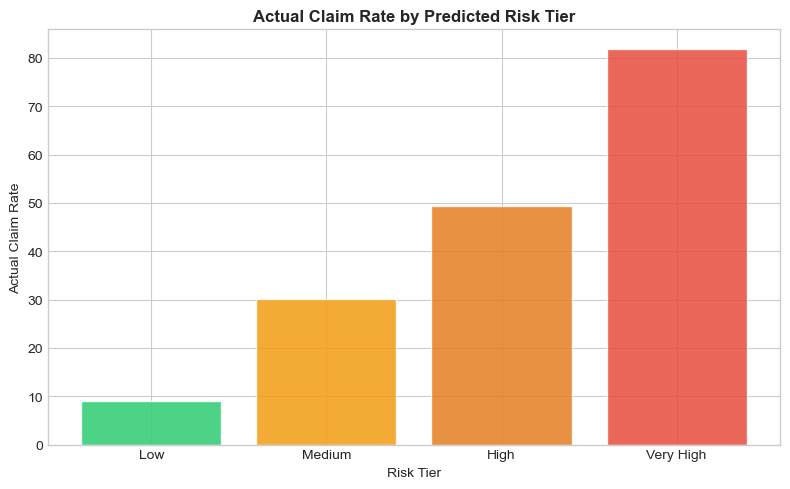

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
tier_order = ['Low','Medium','High','Very High']
tier_colors = ['#2ecc71','#f39c12','#e67e22','#e74c3c']
tier_actual = risk_df.groupby('risk_tier')['actual_claim'].mean() * 100

ax.bar([t for t in tier_order if t in tier_actual.index],
       [tier_actual.get(t, 0) for t in tier_order if t in tier_actual.index],
       color=[tier_colors[i] for i,t in enumerate(tier_order) if t in tier_actual.index],
       alpha=0.85, edgecolor='white')
ax.set_title('Actual Claim Rate by Predicted Risk Tier', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual Claim Rate')
ax.set_xlabel('Risk Tier')
plt.tight_layout()
plt.savefig('farmer_risk_tiers.png', dpi=120, bbox_inches='tight')
plt.show()
